# ASTRA Plotter — 主控笔记本

**基于 BDplotter 代码重构的 ASTRA 数据处理与可视化工具**

本笔记本涵盖 ASTRA 模拟输出的完整分析流程：
- 环境检测与依赖验证
- 数据加载（Emit、Sigma、相空间文件）
- 束流参数统计与分析
- 发射度 / 束斑尺寸 / 能量 / 相空间密度绘图
- 切片分析与亮度计算
- 交互式 GUI（基于 ipywidgets）
- 数据备份与导出

---

**项目结构：**
```
astra_plotter/
├── astra_plotter/          # 核心 Python 包
│   ├── core/               # 数据加载、分析、绘图模块
│   └── utils/              # 环境检测、工具函数
├── gui/                    # GUI 子项目
├── notebooks/              # Jupyter 笔记本
├── scripts/                # CLI 脚本（备份、线图）
├── data/                   # 备份数据存储
├── examples/               # 示例脚本
├── tests/                  # 测试文件
├── docs/                   # 文档（LaTeX 手册）
└── simulation_output/      # 模拟输入输出文件
```


## 1. 环境准备与依赖检查

首先导入必要的标准库，并调用自定义的环境检测模块确认 Python 版本及依赖包均已就绪。

In [37]:
# ============================================================
# 1. 环境准备与依赖检查
# ============================================================
import os
import sys

# 将项目根目录加入 sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"项目根目录: {PROJECT_ROOT}")

# 环境检测
from astra_plotter.utils.env_check import check_environment

# 运行全面环境检查
env_result = check_environment(verbose=True, data_dir=os.path.join(PROJECT_ROOT, 'simulation_output'))

# 如果核心依赖缺失，后续单元格将无法运行
if not env_result['python'][0]:
    raise RuntimeError("Python 版本过低，请升级到 Python >= 3.7")
    
deps_ok = all(v[0] for v in env_result['dependencies'].values())
if not deps_ok:
    print("\n⚠️  部分依赖缺失，请运行: pip install -r requirements.txt")

项目根目录: /Users/yuxinwu/plotter/astra_plotter
  ASTRA Plotter - Environment Check

[1/4] Python Version:
  ✓ Python 3.9 (>= 3.7 required)

[2/4] Required Packages:
  ✓ numpy: OK (installed: 2.0.2)
  ✓ scipy: OK (installed: 1.13.1)
  ✓ matplotlib: OK (installed: 3.9.4)

[3/4] LaTeX Support:
  ✓ LaTeX found in PATH

[4/4] ASTRA Data:
  ✓ Found 9 ASTRA-related files in '/Users/yuxinwu/plotter/astra_plotter/simulation_output'.
    - astra.Zemit.001
    - astra.Xemit.001
    - astra.0500.001
    - astra.Yemit.001
    - astra.Log.001
    - astra.ref.001
    - bunch.ini
    - astra.in
    - generator.in

  ✓ Core environment is ready.


## 2. 配置 Matplotlib 绘图参数

设置统一的绘图风格，包括字体、线条宽度、坐标轴格式等，保证所有输出图表风格一致。

In [38]:
# ============================================================
# 2. 配置 Matplotlib 绘图参数
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

from astra_plotter.core.cosmetics import (
    set_publication_style,
    FormatLabelSci,
    SLAC_DESY_CMAP,
    beam_map,
)

# 应用出版级绘图风格（可切换 usetex=False 若未安装 LaTeX）
use_tex = env_result.get('tex', (False,))[0]  # 根据环境检测结果自动选择
set_publication_style(font_size=14, use_tex=use_tex)
print(f"绘图风格已设置 (usetex={use_tex})")

# 在 notebook 中内联显示图表
%matplotlib inline
print("✓ Matplotlib 配置完成")

Publication style set (font_size=14, usetex=True).
绘图风格已设置 (usetex=True)
✓ Matplotlib 配置完成


## 3. 加载 ASTRA 发射度 (Emit) 文件

使用 `LoadAstraEmit` 加载 `.Xemit`、`.Yemit`、`.Zemit` 文件，获取 RMS 束流参数沿纵向位置的演化。

In [39]:
# ============================================================
# 3. 加载 ASTRA 发射度文件
# ============================================================
from astra_plotter.core.loader import LoadAstraEmit

# 设置数据路径
SIM_DIR = os.path.join(PROJECT_ROOT, 'simulation_output')
ROOTNAME = os.path.join(SIM_DIR, 'astra')
RUN = '001'

# 切换到数据目录以便加载
original_cwd = os.getcwd()
os.chdir(SIM_DIR)

# 加载发射度数据
X, Y, Z, C = LoadAstraEmit('astra', RUN)

os.chdir(original_cwd)

# 展示数据结构
print(f"\nXemit 数据列: {X.dtype.names}")
print(f"数据点数: {len(X)}")
print(f"\n前 5 行 X 向发射度数据:")
for name in X.dtype.names:
    print(f"  {name:<12s}: {X[name][:5]}")

# 若有核心发射度数据
if len(C) > 0:
    print(f"\n核心发射度数据列: {C.dtype.names}")

Loading: astra.Xemit.001
Loading: astra.Yemit.001
Loading: astra.Zemit.001

Xemit 数据列: ('z', 't', 'avg', 'rms', 'rmsprime', 'emit', 'corr')
数据点数: 500

前 5 行 X 向发射度数据:
  z           : [-2.6783e-10  1.0000e-02  2.0000e-02  3.0000e-02  4.0000e-02]
  t           : [0.       0.033356 0.066713 0.10007  0.13343 ]
  avg         : [6.7905e-07 6.7899e-07 6.7892e-07 6.7886e-07 6.7879e-07]
  rms         : [0.5 0.5 0.5 0.5 0.5]
  rmsprime    : [0.0010215 0.0010215 0.0010215 0.0010215 0.0010215]
  emit        : [1. 1. 1. 1. 1.]
  corr        : [6.4902e-10 2.1519e-08 4.2388e-08 6.3258e-08 8.4128e-08]


## 4. 加载 ASTRA 二阶矩 (Sigma) 文件

加载 `.Sigma` 文件获取完整 6×6 束团矩阵，并计算本征发射度。

In [40]:
# ============================================================
# 4. 加载 ASTRA Sigma 文件
# ============================================================
from astra_plotter.core.loader import LoadAstraSigma

os.chdir(SIM_DIR)
try:
    S, enx, eny, enz = LoadAstraSigma('astra', RUN)
    print(f"\nSigma 数据列: {S.dtype.names}")
    print(f"数据点数: {len(S)}")
    print(f"本征发射度 enx 范围: [{enx.min():.4e}, {enx.max():.4e}]")
    print(f"本征发射度 eny 范围: [{eny.min():.4e}, {eny.max():.4e}]")
    has_sigma = True
except FileNotFoundError:
    print("⚠ Sigma 文件未找到，跳过本征发射度分析")
    S, enx, eny, enz = None, None, None, None
    has_sigma = False
finally:
    os.chdir(original_cwd)

Loading: astra.Sigma.001
⚠ Sigma 文件未找到，跳过本征发射度分析


## 5. 加载 ASTRA 相空间文件

加载粒子分布数据，自动筛选存活粒子（status > 0），并转换累积坐标为绝对坐标。

In [41]:
# ============================================================
# 5. 加载 ASTRA 相空间文件
# ============================================================
from astra_plotter.core.loader import LoadAstraPhaseSpace, discover_astra_files

# 自动发现相空间文件
astra_files = discover_astra_files(SIM_DIR, 'astra')
print("发现的 ASTRA 文件:")
for ftype, files in astra_files.items():
    if files:
        print(f"  {ftype}: {len(files)} 个文件")

# 加载第一个相空间文件（最终的粒子分布）
if astra_files['phase']:
    phase_file = astra_files['phase'][-1]  # 取最后一个时间步
    print(f"\n加载相空间文件: {os.path.basename(phase_file)}")
    os.chdir(SIM_DIR)
    PhSp = LoadAstraPhaseSpace(os.path.basename(phase_file))
    os.chdir(original_cwd)
    
    print(f"存活粒子数: {len(PhSp)}")
    print(f"数据列: {PhSp.dtype.names}")
    print(f"x 范围: [{PhSp['x'].min():.4e}, {PhSp['x'].max():.4e}] m")
    print(f"y 范围: [{PhSp['y'].min():.4e}, {PhSp['y'].max():.4e}] m")
    print(f"pz 均值: {PhSp['pz'].mean():.4e} eV/c")
    has_phsp = True
else:
    print("⚠ 未找到相空间文件")
    PhSp = None
    has_phsp = False

发现的 ASTRA 文件:
  Xemit: 1 个文件
  Yemit: 1 个文件
  Zemit: 1 个文件
  ref: 1 个文件
  Log: 1 个文件
  phase: 1 个文件

加载相空间文件: astra.0500.001
  Total particles: 10000, Surviving: 10000
存活粒子数: 10000
数据列: ('x', 'y', 'z', 'px', 'py', 'pz', 'clock', 'charge', 'index', 'status')
x 范围: [-1.7738e-03, 2.1099e-03] m
y 范围: [-1.6954e-03, 1.9786e-03] m
pz 均值: 1.0005e+09 eV/c


## 6. 计算派生物理量

基于加载的数据计算归一化发射度、平均能量、能量散度、束团长度、电流分布等。

In [42]:
# ============================================================
# 6. 计算派生物理量
# ============================================================
from astra_plotter.core.analyzer import Analysis, current, BunchFormFactor
from astra_plotter.utils.helpers import summarize_phsp, format_quantity

if has_phsp:
    # 束流全局统计
    result = Analysis(PhSp)
    
    print("\n" + "=" * 55)
    print("  束流参数统计")
    print("=" * 55)
    print(f"  粒子数            : {result['N']}")
    print(f"  平均 γ            : {result['gamma_avg']:.4f}")
    print(f"  平均 β            : {result['beta_avg']:.4f}")
    print(f"  RMS 束斑 x        : {result['rms_x']*1e3:.4f} mm")
    print(f"  RMS 束斑 y        : {result['rms_y']*1e3:.4f} mm")
    print(f"  RMS 束团长度 z    : {result['rms_z']*1e3:.4f} mm")
    print(f"  归一化发射度 x    : {result['nemit_x']*1e6:.4f} µm")
    print(f"  归一化发射度 y    : {result['nemit_y']*1e6:.4f} µm")
    print(f"  归一化发射度 z    : {result['nemit_z']*1e6:.4f} µm")
    print(f"  相对能散 (rms)    : {result['de_over_e']*100:.4f} %")
    print("=" * 55)
    
    # 电流分布
    bunch_charge = 1.0e-9  # 假设 1 nC（需根据实际设置）
    I, s_z = current(PhSp['z'], bunch_charge, Nbins=50)
    print(f"\n峰值电流: {I.max():.2f} A")
    print(f"束团长度 (rms): {result['rms_z']*1e3:.4f} mm")
    
    # 群聚因子
    k_vals, bff_vals = BunchFormFactor(
        PhSp['z'], kmin=1e-3, kmax=1e3, nk=100, IsLog=True
    )
    print(f"群聚因子计算完成 ({len(k_vals)} 个 k 点)")
else:
    print("⚠ 无相空间数据，跳过统计计算")


  束流参数统计
  粒子数            : 10000
  平均 γ            : 1957.9310
  平均 β            : 1.0000
  RMS 束斑 x        : 0.5000 mm
  RMS 束斑 y        : 0.5000 mm
  RMS 束团长度 z    : 0.8796 mm
  归一化发射度 x    : 1.0001 µm
  归一化发射度 y    : 1.0001 µm
  归一化发射度 z    : 2.5934 µm
  相对能散 (rms)    : 0.5275 %

峰值电流: 125.28 A
束团长度 (rms): 0.8796 mm
群聚因子计算完成 (100 个 k 点)


## 7. 切片分析

沿纵向等间隔切片，计算每个切片的发射度、电流、中心位置、能量散度及亮度。

执行 30 切片分析...
Slice analysis: z range [-1.9971e-03, 1.9993e-03] m, bin width = 1.3781e-04 m, 30 bins

切片分析结果 (30 个切片):
      z (mm)      I (A)    ε_nx (µm)    ε_ny (µm)    σ_E/E (%)
  ------------------------------------------------------------
     -1.9971       9.35  512673.4899  468919.5031       0.0126
     -1.8593      22.41  504510.3775  532784.3892       0.0242
     -1.7215      28.28  520539.4365  474888.5426       0.0241
     -1.5837      35.89  475912.7171  496049.2742       0.0240
     -1.4459      43.94  515508.2175  537909.5579       0.0239

  开始生成标准图表

▶ 绘制发射度曲线...


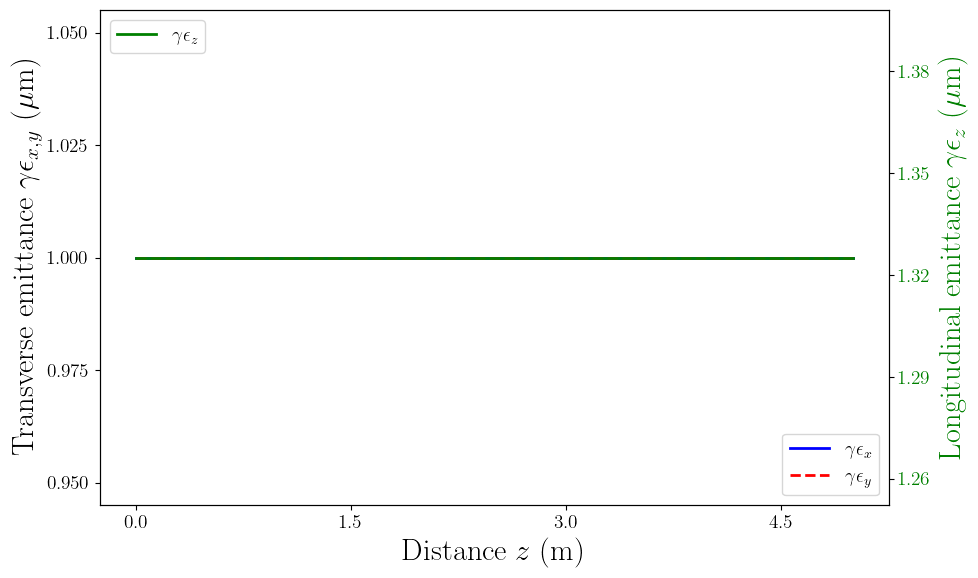

▶ 绘制束斑尺寸曲线...


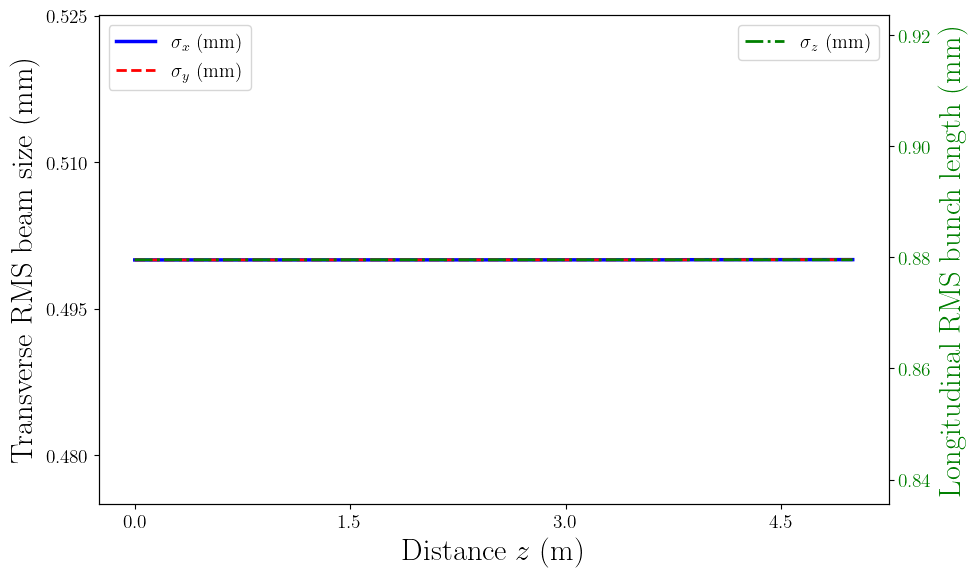

▶ 绘制能量与能散曲线...


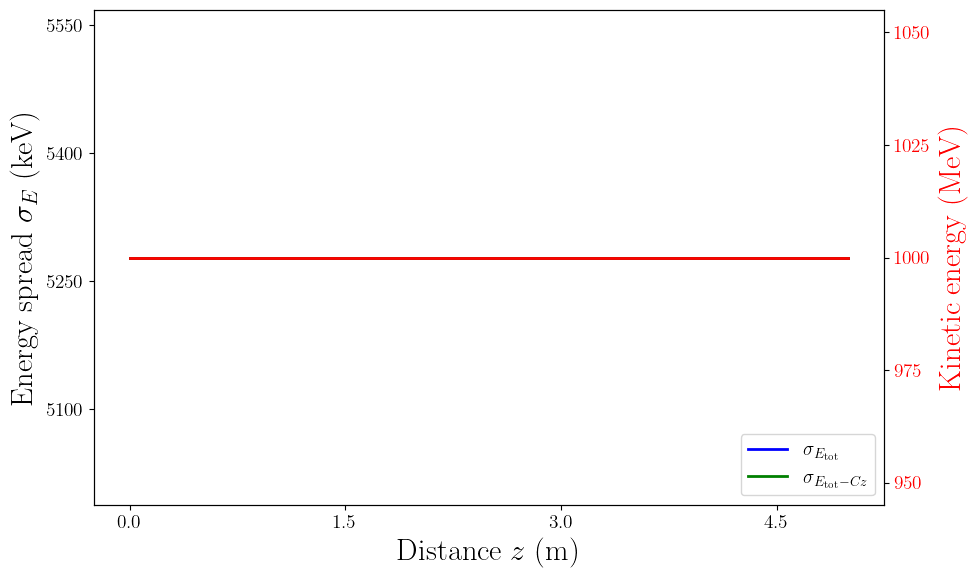

▶ 绘制横向相空间密度图...


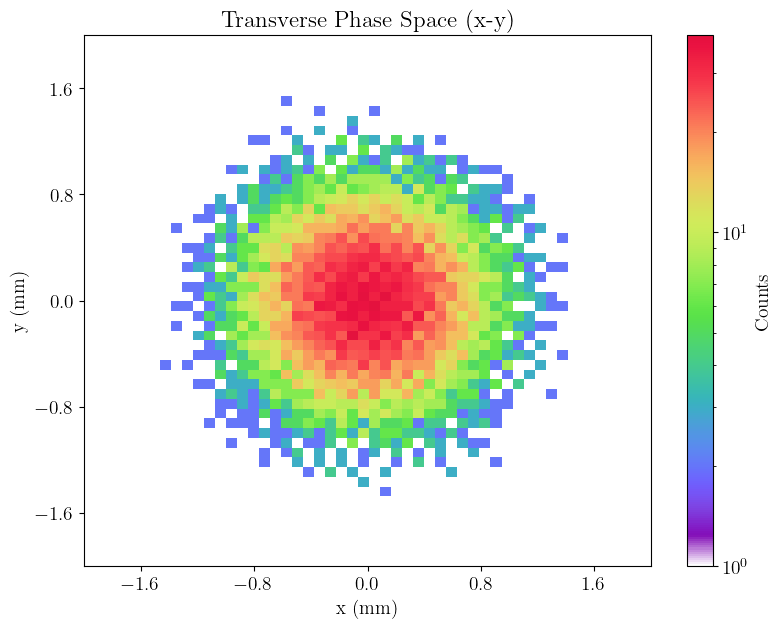

▶ 绘制纵向相空间密度图...


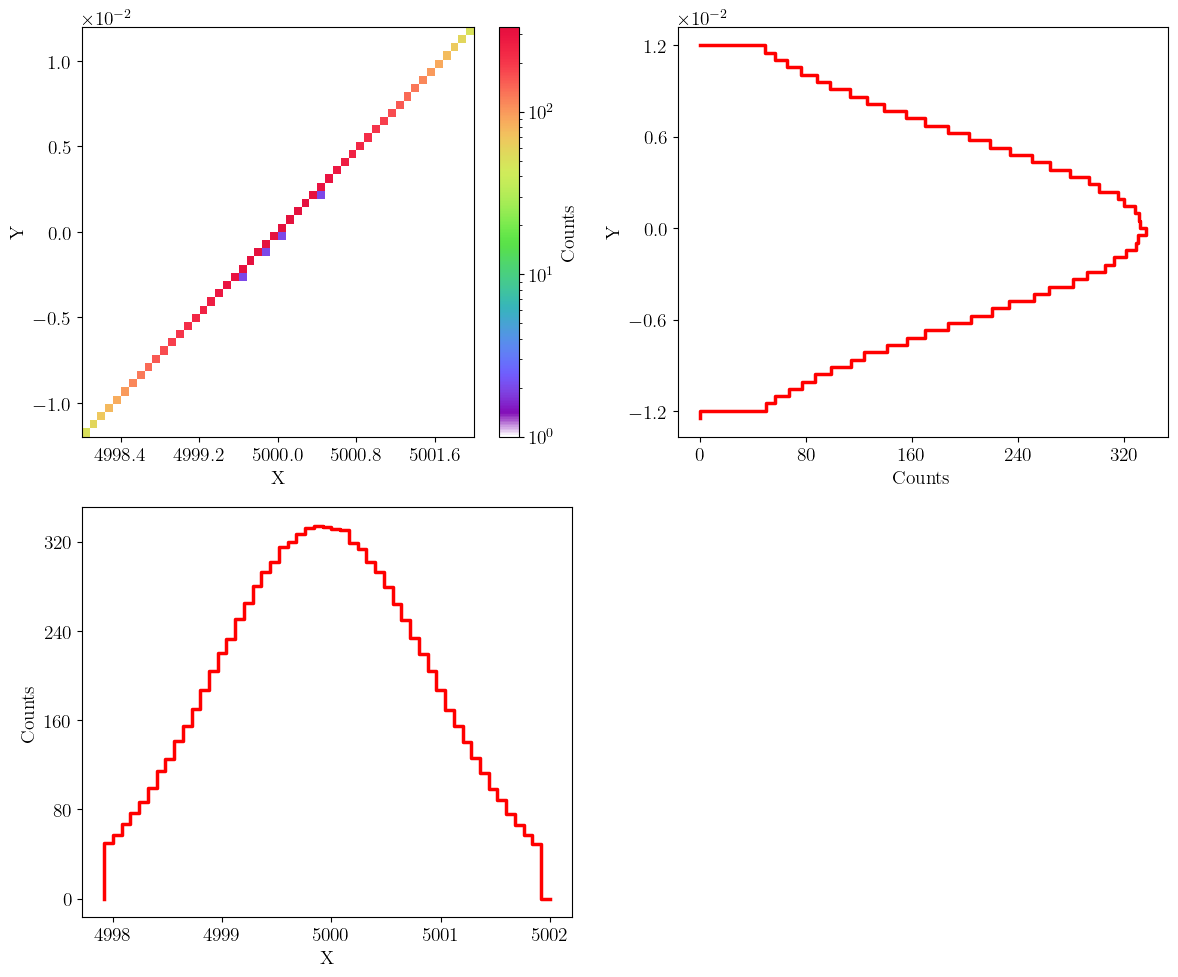

▶ 绘制切片分析图...


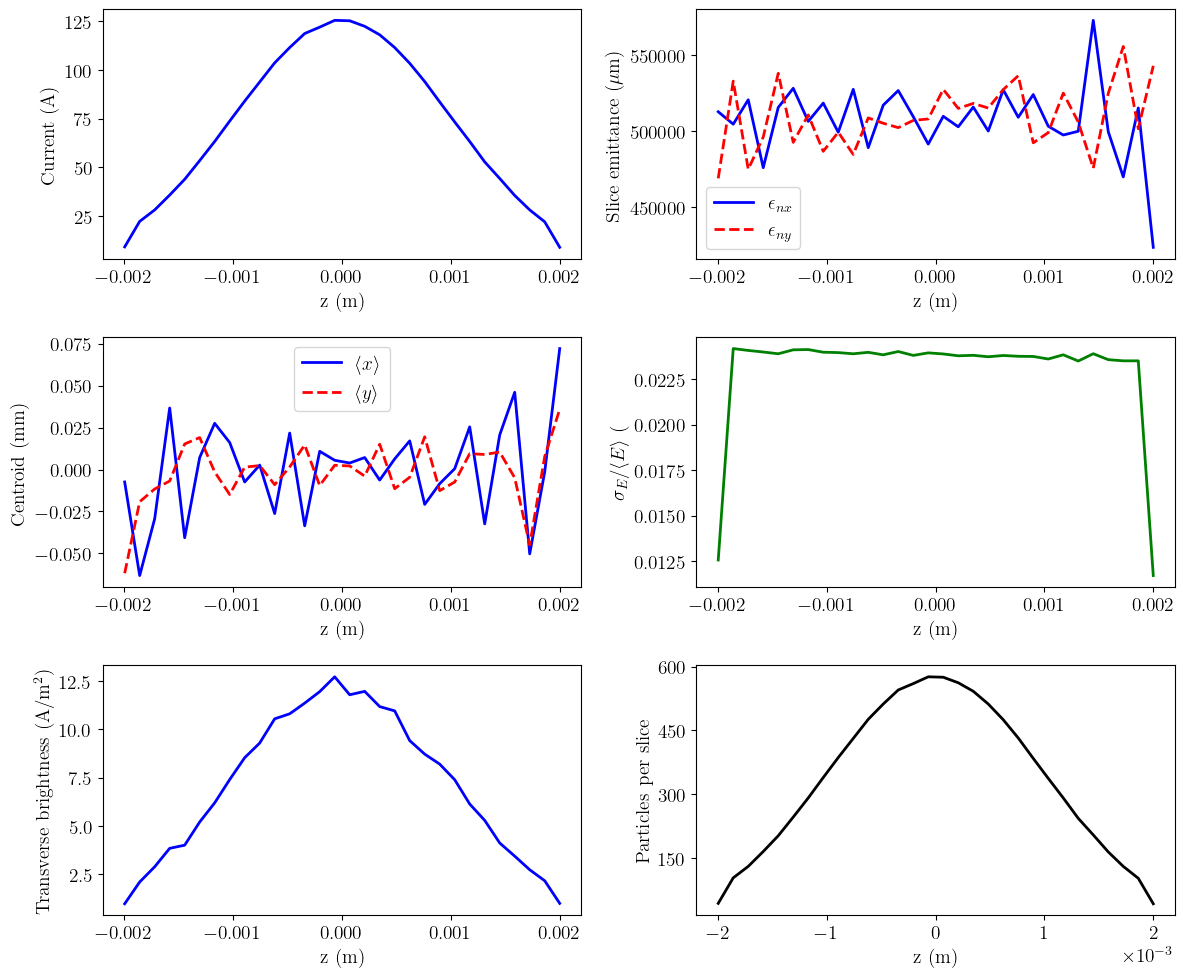

▶ 绘制群聚因子...


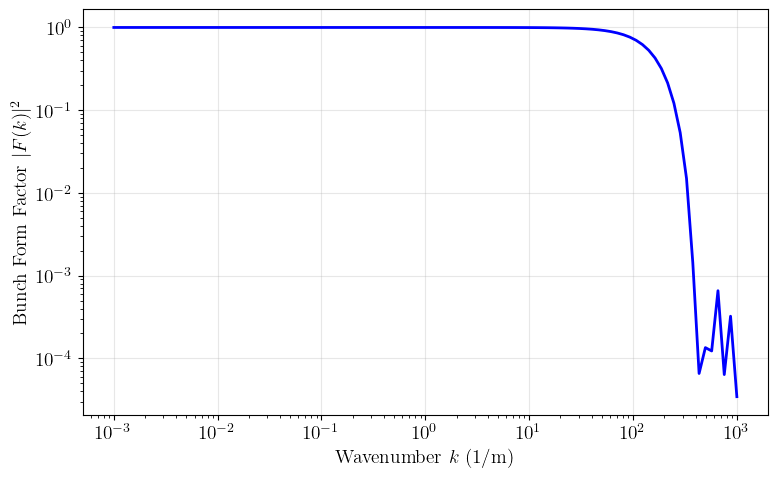


✓ 所有图表生成完毕


In [43]:
# ============================================================
# 7. 切片分析
# ============================================================
from astra_plotter.core.analyzer import UniformSliceAnalysis

if has_phsp:
    NUM_SLICES = 30
    bunch_charge = 1.0e-9  # 假设 1 nC
    
    print(f"执行 {NUM_SLICES} 切片分析...")
    sliceMatrix = UniformSliceAnalysis(PhSp, NUM_SLICES, bunch_charge)
    
    # 展示切片结果摘要
    print(f"\n切片分析结果 ({NUM_SLICES} 个切片):")
    print(f"  {'z (mm)':>10s} {'I (A)':>10s} {'ε_nx (µm)':>12s} "
          f"{'ε_ny (µm)':>12s} {'σ_E/E (%)':>12s}")
    print("  " + "-" * 60)
    
    # 展示前 5 个有意义的切片
    shown = 0
    for i in range(len(sliceMatrix)):
        if sliceMatrix[i, 2] > 5:  # 至少 5 个粒子
            print(f"  {sliceMatrix[i,0]*1e3:10.4f} {sliceMatrix[i,4]:10.2f} "
                  f"{sliceMatrix[i,8]*1e6:12.4f} {sliceMatrix[i,9]*1e6:12.4f} "
                  f"{sliceMatrix[i,10]*100:12.4f}")
            shown += 1
            if shown >= 5:
                break
    
    has_slices = True
else:
    print("⚠ 无相空间数据，跳过切片分析")
    sliceMatrix = None
    has_slices = False


# ============================================================
# 8-11. 绘图区域
# ============================================================

from astra_plotter.core.plotter import (
    PlotEmit1plt, PlotSize1plt, PlotEnergy1plt, PlotEigenEmits,
    PlotTransSize1plt, DensityPlot, DensityPlot_w_proj,
    DensityplotwProjec2x2, PlotSliceParameters, PlotBunchFormFactor
)

print("\n" + "=" * 55)
print("  开始生成标准图表")
print("=" * 55)

# --- 8. 发射度曲线 ---
print("\n▶ 绘制发射度曲线...")
fig_emit = PlotEmit1plt(X, Y, Z)
plt.show()

# --- 9. 束斑尺寸曲线 ---
print("▶ 绘制束斑尺寸曲线...")
fig_size = PlotSize1plt(X, Y, Z)
plt.show()

# --- 10. 能量与能散曲线 ---
print("▶ 绘制能量与能散曲线...")
fig_energy = PlotEnergy1plt(X, Y, Z)
plt.show()

# --- 本征发射度 (若有 Sigma 数据) ---
if has_sigma:
    print("▶ 绘制本征发射度...")
    fig_eigen = PlotEigenEmits(S, enx, eny, enz)
    plt.show()

# --- 11. 相空间密度图 ---
if has_phsp:
    print("▶ 绘制横向相空间密度图...")
    fig_density = DensityPlot(
        PhSp['x'] * 1e3, PhSp['y'] * 1e3, Nbins=50,
        axis=[-2, 2, -2, 2]  # mm 范围
    )
    plt.title('Transverse Phase Space (x-y)')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.show()
    
    print("▶ 绘制纵向相空间密度图...")
    fig_long = DensityplotwProjec2x2(
        PhSp['z'] * 1e3, PhSp['pz'] / PhSp['pz'].mean() - 1,
        Nbins=50
    )
    plt.show()
    
    # 切片参数图
    if has_slices:
        print("▶ 绘制切片分析图...")
        fig_slices = PlotSliceParameters(sliceMatrix)
        plt.show()
    
    # 群聚因子图
    print("▶ 绘制群聚因子...")
    fig_bff = PlotBunchFormFactor(k_vals, bff_vals)
    plt.show()
else:
    print("⚠ 无相空间数据，跳过密度图")

print("\n✓ 所有图表生成完毕")

## 8. 绘制发射度曲线

使用 `PlotEmit1plt` 在同一图中绘制 x、y、z 三个方向的发射度随纵向位置的演化。

▶ 绘制发射度曲线...


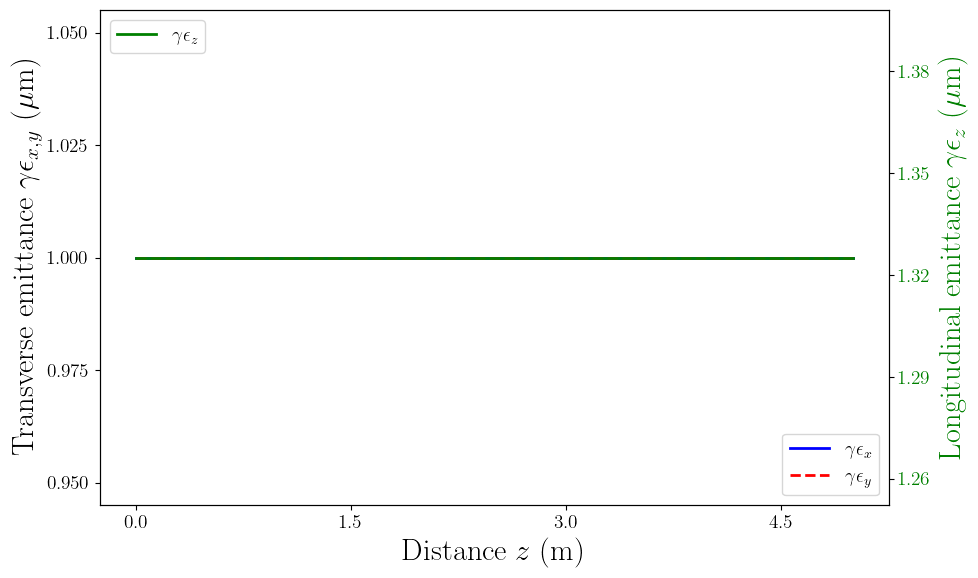

In [44]:
# ============================================================
# 8. 绘制发射度曲线
# ============================================================
from astra_plotter.core.plotter import PlotEmit1plt

print("▶ 绘制发射度曲线...")
fig_emit = PlotEmit1plt(X, Y, Z)
plt.show()

## 9. 绘制束斑尺寸曲线

绘制横向和纵向 RMS 束斑尺寸的对比图。

▶ 绘制束斑尺寸曲线...


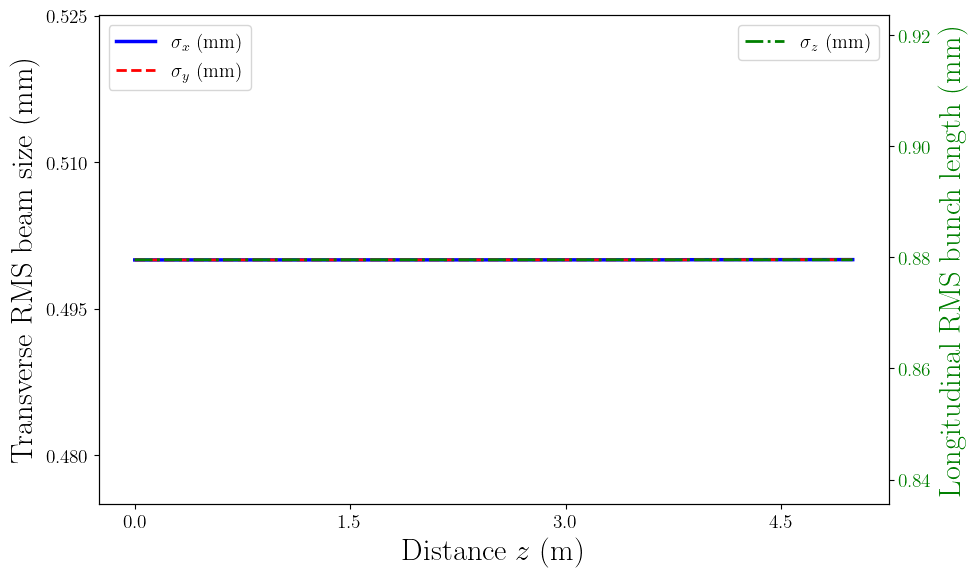

In [45]:
# ============================================================
# 9. 绘制束斑尺寸曲线
# ============================================================
from astra_plotter.core.plotter import PlotSize1plt

print("▶ 绘制束斑尺寸曲线...")
fig_size = PlotSize1plt(X, Y, Z)
plt.show()

## 10. 绘制能量与能散曲线

绘制束流平均动能、总能散和部分相关能散随位置的变化。

▶ 绘制能量与能散曲线...


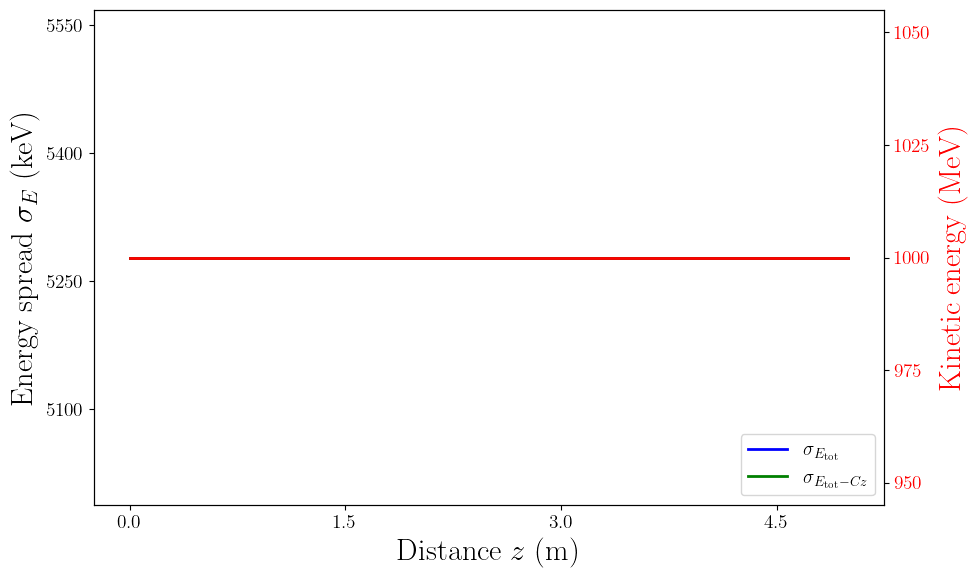

In [46]:
# ============================================================
# 10. 绘制能量与能散曲线
# ============================================================
from astra_plotter.core.plotter import PlotEnergy1plt

print("▶ 绘制能量与能散曲线...")
fig_energy = PlotEnergy1plt(X, Y, Z)
plt.show()

## 11. 绘制相空间密度图

生成横向和纵向相空间的二维直方图，并叠加边缘投影。

▶ 绘制横向相空间 (x-y) 密度图...


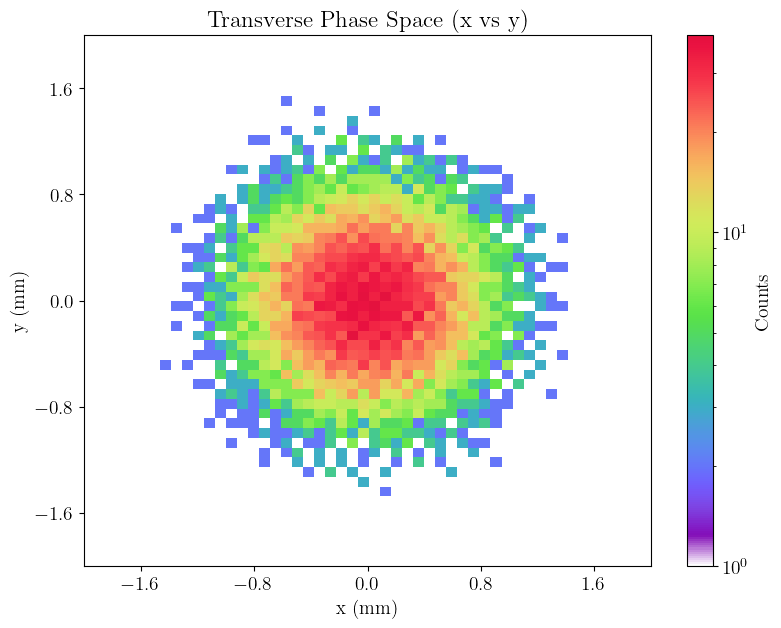

▶ 绘制横向相空间 (x-px) 带投影...


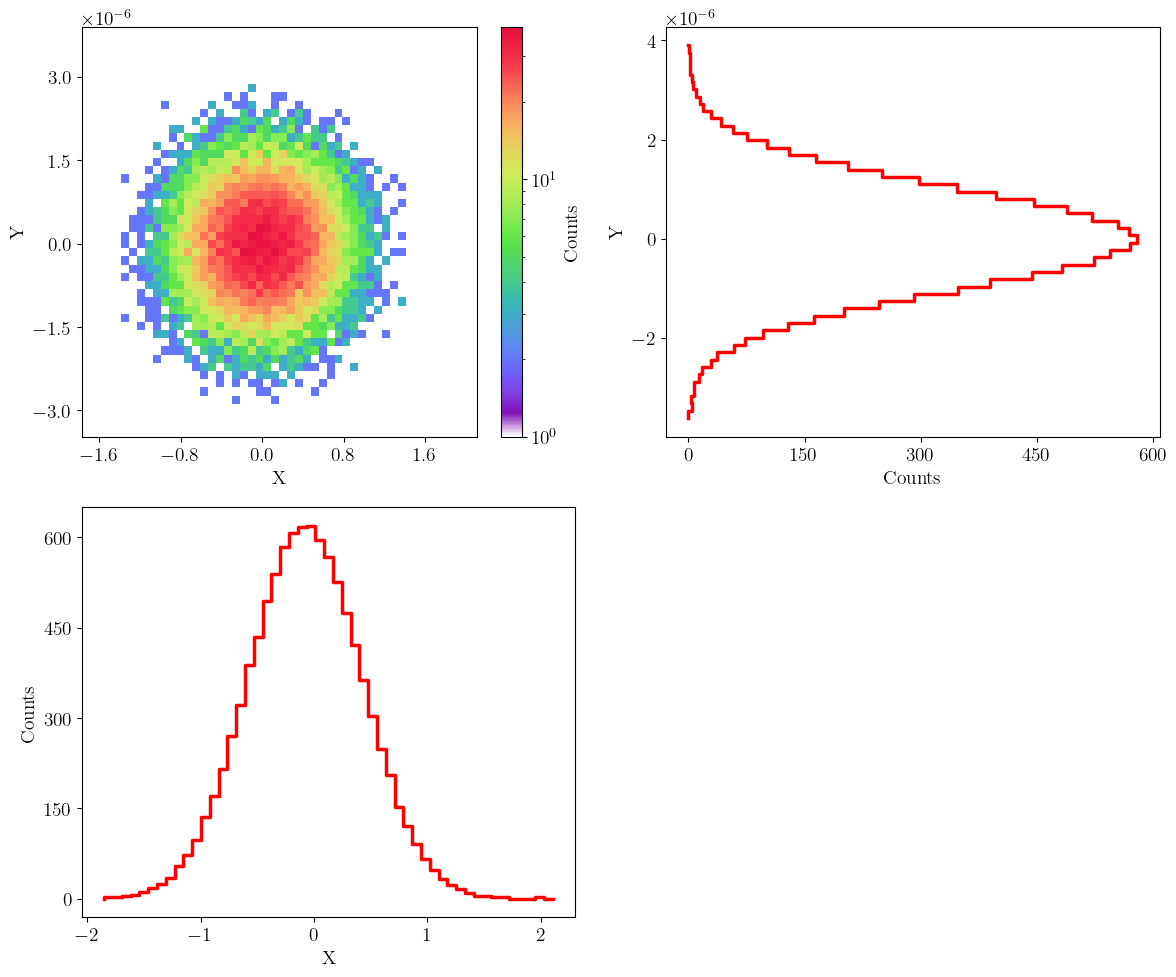

▶ 绘制纵向相空间 (z-Δp/p) ...


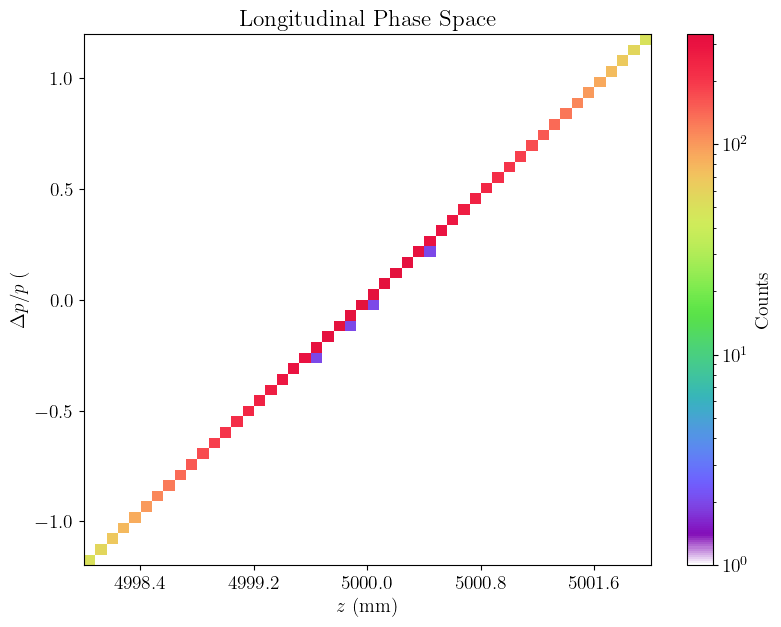

▶ 绘制切片分析结果...


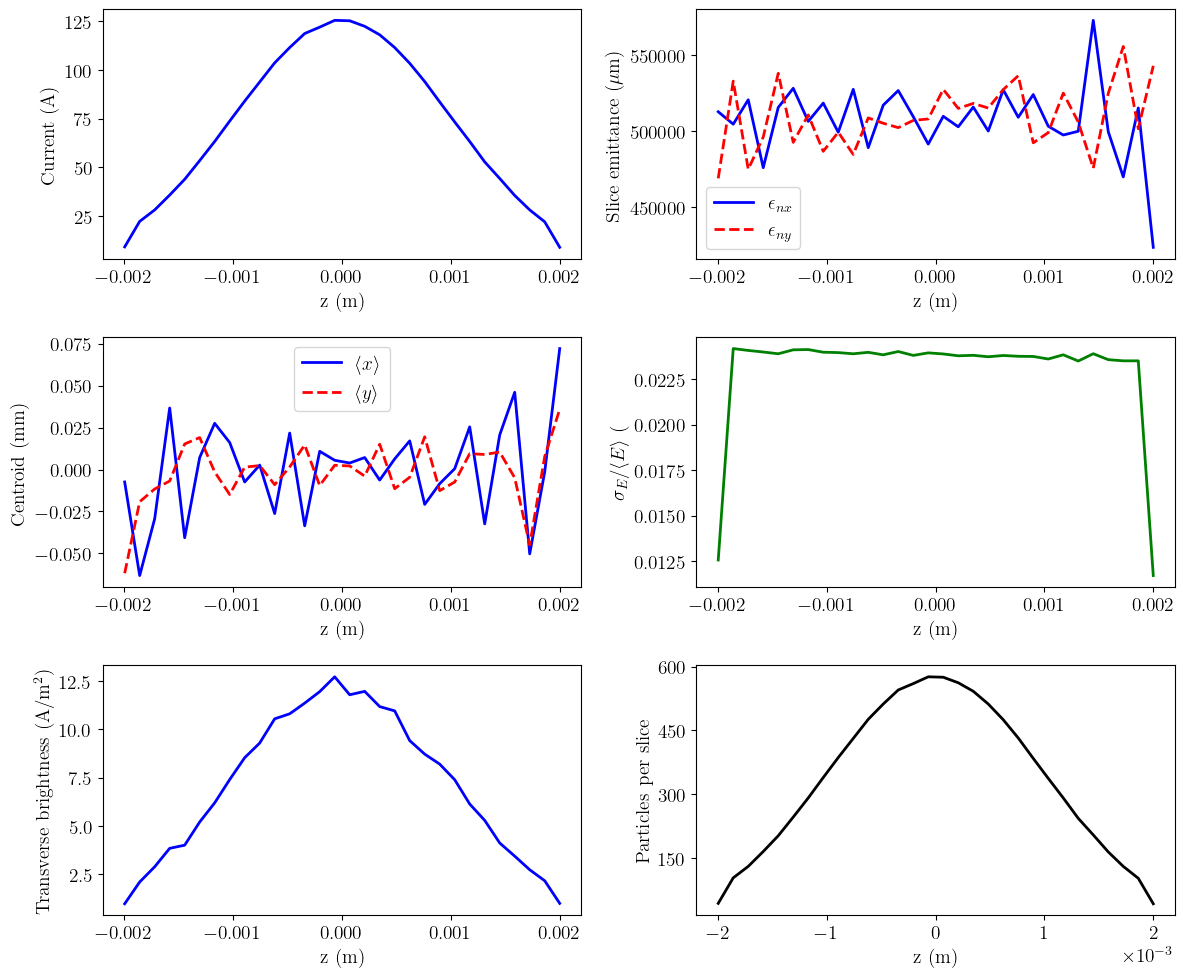

▶ 绘制群聚因子...


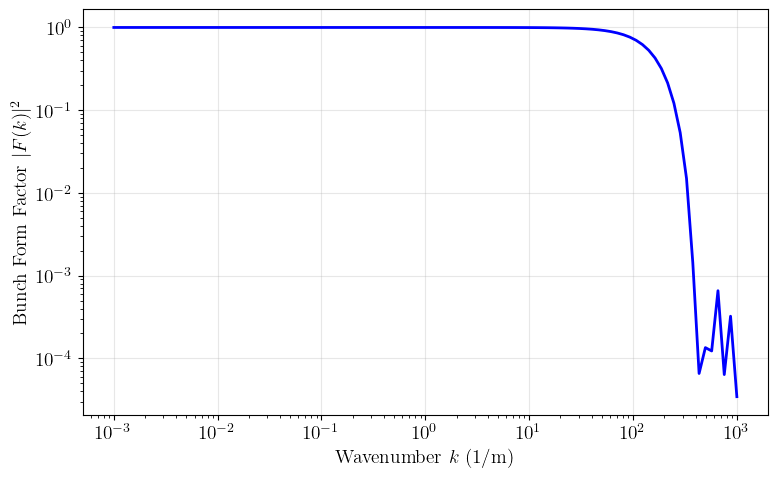

In [47]:
# ============================================================
# 11. 绘制相空间密度图
# ============================================================
from astra_plotter.core.plotter import (
    DensityPlot,
    DensityPlot_w_proj,
    DensityplotwProjec2x2,
    PlotSliceParameters,
    PlotBunchFormFactor,
    PlotEigenEmits,
)

if has_phsp:
    # 横向相空间 (x-y)
    print("▶ 绘制横向相空间 (x-y) 密度图...")
    fig_xy = DensityPlot(
        PhSp['x'] * 1e3, PhSp['y'] * 1e3, Nbins=50,
        axis=[-2, 2, -2, 2]
    )
    plt.title('Transverse Phase Space (x vs y)')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.show()
    
    # 横向相空间 (x-x') 带投影
    print("▶ 绘制横向相空间 (x-px) 带投影...")
    x_norm = PhSp['px'] / np.mean(PhSp['pz'])
    fig_xpx = DensityplotwProjec2x2(PhSp['x'] * 1e3, x_norm, Nbins=50)
    plt.show()
    
    # 纵向相空间 (z-pz)
    print("▶ 绘制纵向相空间 (z-Δp/p) ...")
    delta_p = PhSp['pz'] / np.mean(PhSp['pz']) - 1.0
    fig_zpz = DensityPlot(
        PhSp['z'] * 1e3, delta_p * 100, Nbins=50
    )
    plt.title('Longitudinal Phase Space')
    plt.xlabel(r'$z$ (mm)')
    plt.ylabel(r'$\Delta p/p$ (%)')
    plt.show()
    
    # 切片参数图
    if has_slices:
        print("▶ 绘制切片分析结果...")
        fig_slices = PlotSliceParameters(sliceMatrix)
        plt.show()
    
    # 群聚因子
    print("▶ 绘制群聚因子...")
    fig_bff = PlotBunchFormFactor(k_vals, bff_vals)
    plt.show()
else:
    print("⚠ 无相空间数据，跳过密度图")

# 本征发射度（若有 Sigma 数据）
if has_sigma:
    print("▶ 绘制本征发射度...")
    fig_eigen = PlotEigenEmits(S, enx, eny, enz)
    plt.show()

## 12. 交互式 GUI

基于 ipywidgets 构建简单的图形用户界面，复现 ASTRA postpro 的主要交互功能：
- 文件选择
- 绘图类型切换（发射度/束斑/能量/相空间）
- 参数滑动条（bin 数量、坐标范围等）

In [48]:
# ============================================================
# 12. 交互式 GUI（基于 ipywidgets）
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

# 如果 ipywidgets 未安装，提供安装提示
try:
    import ipywidgets
except ImportError:
    print("⚠ ipywidgets 未安装。请运行: pip install ipywidgets")
    print("交互式 GUI 功能将不可用。")

# ---- 简易交互式后处理 GUI ----
print("\n" + "=" * 55)
print("  ASTRA PostPro 交互式界面")
print("=" * 55)

# 控件定义
plot_type_dropdown = widgets.Dropdown(
    options=[
        ('发射度曲线', 'emit'),
        ('束斑尺寸曲线', 'size'),
        ('能量与能散', 'energy'),
        ('横向相空间 (x-y)', 'phase_xy'),
        ('横向相空间 (x-px)', 'phase_xpx'),
        ('纵向相空间 (z-Δp)', 'phase_zpz'),
        ('切片分析', 'slices'),
        ('本征发射度', 'eigen'),
    ],
    value='emit',
    description='绘图类型:',
    style={'description_width': 'initial'}
)

nbins_slider = widgets.IntSlider(
    value=50, min=10, max=200, step=10,
    description='Bin 数量:',
    style={'description_width': 'initial'}
)

xlim_slider = widgets.FloatSlider(
    value=2.0, min=0.5, max=20, step=0.5,
    description='坐标范围 (±mm):',
    style={'description_width': 'initial'}
)

plot_button = widgets.Button(
    description='生成图表',
    button_style='primary',
    icon='bar-chart'
)

output_area = widgets.Output()

# 回调函数
def on_plot_button_clicked(b):
    with output_area:
        clear_output(wait=True)
        plot_type = plot_type_dropdown.value
        nbins = nbins_slider.value
        xlim = abs(xlim_slider.value)  # ensure positive
        
        if plot_type == 'emit':
            PlotEmit1plt(X, Y, Z)
        elif plot_type == 'size':
            PlotSize1plt(X, Y, Z)
        elif plot_type == 'energy':
            PlotEnergy1plt(X, Y, Z)
        elif plot_type == 'phase_xy' and has_phsp:
            DensityPlot(PhSp['x']*1e3, PhSp['y']*1e3,
                       Nbins=nbins, axis=[-xlim, xlim, -xlim, xlim])
            plt.xlabel(r'$x$ (mm)'); plt.ylabel(r'$y$ (mm)')
        elif plot_type == 'phase_xpx' and has_phsp:
            DensityplotwProjec2x2(
                PhSp['x']*1e3,
                PhSp['px']/np.mean(PhSp['pz']),
                Nbins=nbins
            )
        elif plot_type == 'phase_zpz' and has_phsp:
            DensityPlot(
                PhSp['z']*1e3,
                (PhSp['pz']/np.mean(PhSp['pz'])-1)*100,
                Nbins=nbins
            )
            plt.xlabel(r'$z$ (mm)')
            plt.ylabel(r'$\Delta p/p$ (%)')
        elif plot_type == 'slices' and has_slices:
            PlotSliceParameters(sliceMatrix)
        elif plot_type == 'eigen' and has_sigma:
            PlotEigenEmits(S, enx, eny, enz)
        else:
            print("⚠ 所需数据未加载，请检查前面的数据加载步骤")
        
        plt.show()

plot_button.on_click(on_plot_button_clicked)

# 显示 GUI
gui_box = widgets.VBox([
    widgets.HBox([plot_type_dropdown, nbins_slider]),
    widgets.HBox([xlim_slider, plot_button]),
    output_area
])

display(gui_box)
print("\n💡 选择绘图类型和参数后，点击「生成图表」按钮")


  ASTRA PostPro 交互式界面



💡 选择绘图类型和参数后，点击「生成图表」按钮


## 13. 图表与数据备份

一键备份生成的图表（PNG/PDF）和对应的绘图数据（NumPy .npz），
按时间戳归档到 `data/` 目录。**不备份原始输入文件，只保存绘图结果。**

In [49]:
# ============================================================
# 13. 图表与数据备份
# ============================================================
from scripts.backup import backup_figures_and_data

# ---- 收集所有已生成的图表 ----
figures_to_backup = {}

# 发射度、束斑、能量图（section 15 已生成）
if 'fig_emit' in dir() and fig_emit is not None:
    figures_to_backup['emittance_evolution'] = fig_emit
if 'fig_size' in dir() and fig_size is not None:
    figures_to_backup['beam_size_evolution'] = fig_size
if 'fig_energy' in dir() and fig_energy is not None:
    figures_to_backup['energy_evolution'] = fig_energy

# 相空间密度图
if 'fig_xy' in dir() and fig_xy is not None:
    figures_to_backup['phase_space_xy'] = fig_xy
if 'fig_xpx' in dir() and fig_xpx is not None:
    figures_to_backup['phase_space_xpx'] = fig_xpx
if 'fig_zpz' in dir() and fig_zpz is not None:
    figures_to_backup['phase_space_zpz'] = fig_zpz

# 切片分析 & 群聚因子
if 'fig_slices' in dir() and fig_slices is not None:
    figures_to_backup['slice_analysis'] = fig_slices
if 'fig_bff' in dir() and fig_bff is not None:
    figures_to_backup['bunch_form_factor'] = fig_bff

# ---- 收集绘图数据 ----
data_to_backup = {}

# Emit 数据
data_to_backup['emit_data'] = {
    'z': X['z'],
    'X_rms': X['rms'], 'X_emit': X['emit'],
    'Y_rms': Y['rms'], 'Y_emit': Y['emit'],
    'Z_rms': Z['rms'], 'Z_emit': Z['emit'],
}

# 相空间 & 统计
if has_phsp:
    data_to_backup['phasespace'] = {
        'x': PhSp['x'], 'y': PhSp['y'], 'z': PhSp['z'],
        'px': PhSp['px'], 'py': PhSp['py'], 'pz': PhSp['pz'],
    }
    if 'result' in dir() and result is not None:
        data_to_backup['statistics'] = result
    if has_slices:
        data_to_backup['slice_matrix'] = sliceMatrix

# ---- 执行备份 ----
backup_figures_and_data(
    figures=figures_to_backup,
    data_dict=data_to_backup,
    notes=f'ASTRA: {os.path.basename(ROOTNAME)}, run {RUN}',
    fmt='png',
    dpi=150,
    verbose=True,
)

print("\n💡 也可命令行运行: python scripts/backup.py")

  ASTRA Plotter - 图表与数据备份
  输出目录: /Users/yuxinwu/plotter/astra_plotter/data/20260703_182856
------------------------------------------------------------

[图表]
  ✓ emittance_evolution.png             49.4 KB
  ✓ beam_size_evolution.png             55.0 KB
  ✓ energy_evolution.png                38.5 KB
  ✓ phase_space_xy.png                  4.6 KB
  ✓ phase_space_xpx.png                 49.4 KB
  ✓ phase_space_zpz.png                 4.6 KB
  ✓ slice_analysis.png                  187.5 KB
  ✓ bunch_form_factor.png               29.9 KB

[数据]
  ✓ emit_data.npz                       2.7 KB
  ✓ phasespace.npz                      310.2 KB
  ✓ statistics.npz                      3.0 KB
  ✓ slice_matrix.npz                    3.1 KB
  ✓ statistics.json
------------------------------------------------------------
  共 13 个项目已备份
  位置: /Users/yuxinwu/plotter/astra_plotter/data/20260703_182856

💡 也可命令行运行: python scripts/backup.py


<Figure size 640x480 with 0 Axes>

## 14. 端到端分析示例

串联所有步骤，展示完整分析工作流：加载数据 → 计算参数 → 生成图表 → 保存 → 备份。

### 工作流总结

| 步骤 | 模块 | 功能 |
|------|------|------|
| 1 | `env_check` | 环境检测 |
| 2 | `loader` | 加载 Emit / Sigma / 相空间文件 |
| 3 | `analyzer` | 束流统计、电流分布、切片分析 |
| 4 | `plotter` | 发射度、束斑、能量、相空间密度图 |
| 5 | GUI | 交互式图表选择与参数调节 |
| 6 | Backup | 数据备份与图表导出 |

### 快速使用

```python
# 一键式分析
from astra_plotter import *
from astra_plotter.core.cosmetics import set_publication_style
import os

# 设置
set_publication_style(font_size=14, use_tex=False)
os.chdir('simulation_output')

# 加载
X, Y, Z, C = LoadAstraEmit('astra', '001')
PhSp = LoadAstraPhaseSpace('astra.0500.001')

# 分析
result = Analysis(PhSp)
slices = UniformSliceAnalysis(PhSp, 30, 1e-9)

# 绘图
PlotEmit1plt(X, Y, Z)
PlotSize1plt(X, Y, Z)
DensityPlot(PhSp['x']*1e3, PhSp['y']*1e3, 50)
```

---

**项目完成！** 🎉 如需扩展功能，请参考 `astra_plotter/core/` 中的模块结构添加新的 loader、analyzer 或 plotter 函数。